# Dataset inspection

This notebook inspects a registered OCEL dataset as a RelBench database. Each section now focuses on one question at a time so the tables and figures are easier to interpret in isolation.

Every analysis cell starts with a source link to the exact helper function that produces the result. That makes it easier to move between the notebook narrative and the implementation in `scripts/inspection/utils/`.


In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve().parents[1]
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from data.dataset import register_all_datasets

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from scripts.inspection.utils import configure_plot_style

configure_plot_style()

DATASET_NAME = "container_logistics"
SAVE_FIGURES = False

print(f"Working directory: {Path.cwd()}")

register_all_datasets()


/home/msousa-poza/marco/ocel-ocp/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working directory: /home/msousa-poza/marco/ocel-ocp


In [2]:
from relbench.datasets import get_dataset

ds = get_dataset(DATASET_NAME, download=False)
db = ds.get_db()


Loading Database object from /home/msousa-poza/.cache/relbench/container_logistics/db...
Done in 0.18 seconds.


## 1. Schema overview

Start with the table inventory and parsed dtypes. This is the fastest sanity check for whether the OCEL import produced the expected RelBench structure before looking at any distributions.


In [3]:
from scripts.inspection.utils import describe_tables

schema = describe_tables(db)
display(schema["table_overview"])
display(schema["column_dtypes"])


,table,rows,columns,num_columns
0,e2o,64065,4,4
1,event,30504,3,3
2,o2o,13784,4,4
3,object,11999,3,3
4,object_attr_Container,5155,5,5
5,object_attr_Customer Order,514,3,3
6,object_attr_Transport Document,1495,4,4
7,object_attr_Vehicle,107,3,3


,table,column,dtype
0,e2o,event_id,int64
1,e2o,object_id,int64
2,e2o,qualifier,string
3,e2o,time,datetime64[ns]
4,event,event_id,int64
5,event,time,datetime64[ns]
6,event,type,string
7,o2o,object_id_dst,int64
8,o2o,object_id_src,int64
9,o2o,qualifier,string


## 2. Targeted dtype check

This pass focuses on selected business attributes such as `Weight` and `Status`. The goal is to verify that numerics remained numeric and that status-like fields did not get silently parsed into an unexpected dtype.


In [4]:
from scripts.inspection.utils import inspect_attribute_dtypes

typed_checks = inspect_attribute_dtypes(db)
for table_name, dtypes, preview in typed_checks:
    display(Markdown(f"### `{table_name}`"))
    display(dtypes)
    display(preview)


### `object_attr_Container`

,column,dtype
0,Status,string
1,Weight,string


,Status,Weight
0,empty,null
1,full,null
2,full,1120.0
3,empty,null
4,full,null
5,full,1160.0
6,empty,null
7,full,null
8,full,1180.0
9,empty,null


### `object_attr_Transport Document`

,column,dtype
0,Status,string


,Status
0,null
1,in transit
2,shipped
3,null
4,in transit
5,shipped
6,null
7,in transit
8,shipped
9,null


## 3. Event type composition

This table shows which event families dominate the log. Strong imbalance here often propagates into both temporal plots and downstream task targets.


In [5]:
from scripts.inspection.utils import event_type_counts

display(event_type_counts(db))


,event_type,count
0,Collect Goods,9117
1,Load Truck,9116
2,Pick Up Empty Container,1721
3,Drive to Terminal,1717
4,Weigh,1717
5,Bring to Loading Bay,1684
6,Load to Vehicle,1684
7,Place in Stock,1571
8,Register Customer Order,514
9,Create Transport Document,510


## 4. Object type composition

Object type counts complement the event view. They reveal whether the process is centered around a few dominant object classes or spread across many object populations.


In [6]:
from scripts.inspection.utils import object_type_counts

display(object_type_counts(db))


,object_type,count
0,Handling Unit,9117
1,Container,1735
2,Customer Order,514
3,Transport Document,510
4,Vehicle,114
5,Truck,6
6,Forklift,3


## 5. Event volume over time

This line plot tracks event activity per day. Read it as a demand or workload profile: sharp spikes suggest bursts, long flat regions suggest inactivity, and diverging colored lines indicate type-specific seasonality.


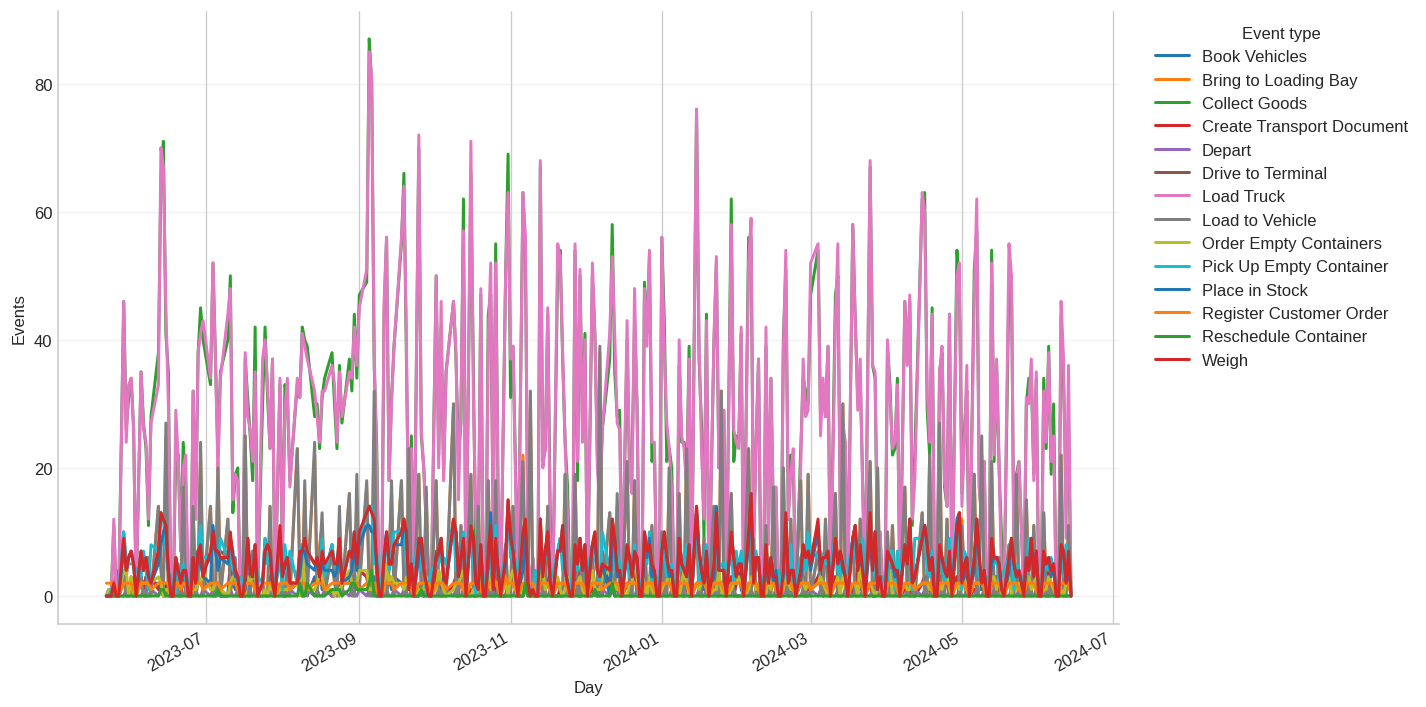

In [7]:
from scripts.inspection.utils import event_histogram, save_figure

event_hist = event_histogram(db, freq="D", by_type=True)
event_hist_pivot = event_hist.pivot(index="bucket", columns="type", values="count").fillna(0).sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
event_hist_pivot.plot(ax=ax, linewidth=1.8)
ax.set_xlabel("Day")
ax.set_ylabel("Events")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(title="Event type", loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()

display(fig)
plt.close(fig)
if SAVE_FIGURES:
    save_figure(fig, dataset_name=DATASET_NAME, stem="figures/event_histogram_daily_by_type")


## 6. Object creation over time

This plot uses the same daily bucketing, but for object creation timestamps. Comparing it with the event plot helps separate workload changes from changes in the rate at which new business entities enter the process.


## 7. Sampled graph size by delta

This section approximates the size of a time-filtered OCEL graph without sweeping the full database. It samples multiple observed root times, keeps the events in each forward-looking window, and counts both the events and the linked objects. The curves show how expected graph size grows with the delta, while the shaded bands show uncertainty over the sampled roots.


Sampled root times: **100**  |  Deltas: **1h, 3h, 6h, 12h, 1D, 2D, 5D**  |  CI: **95%**

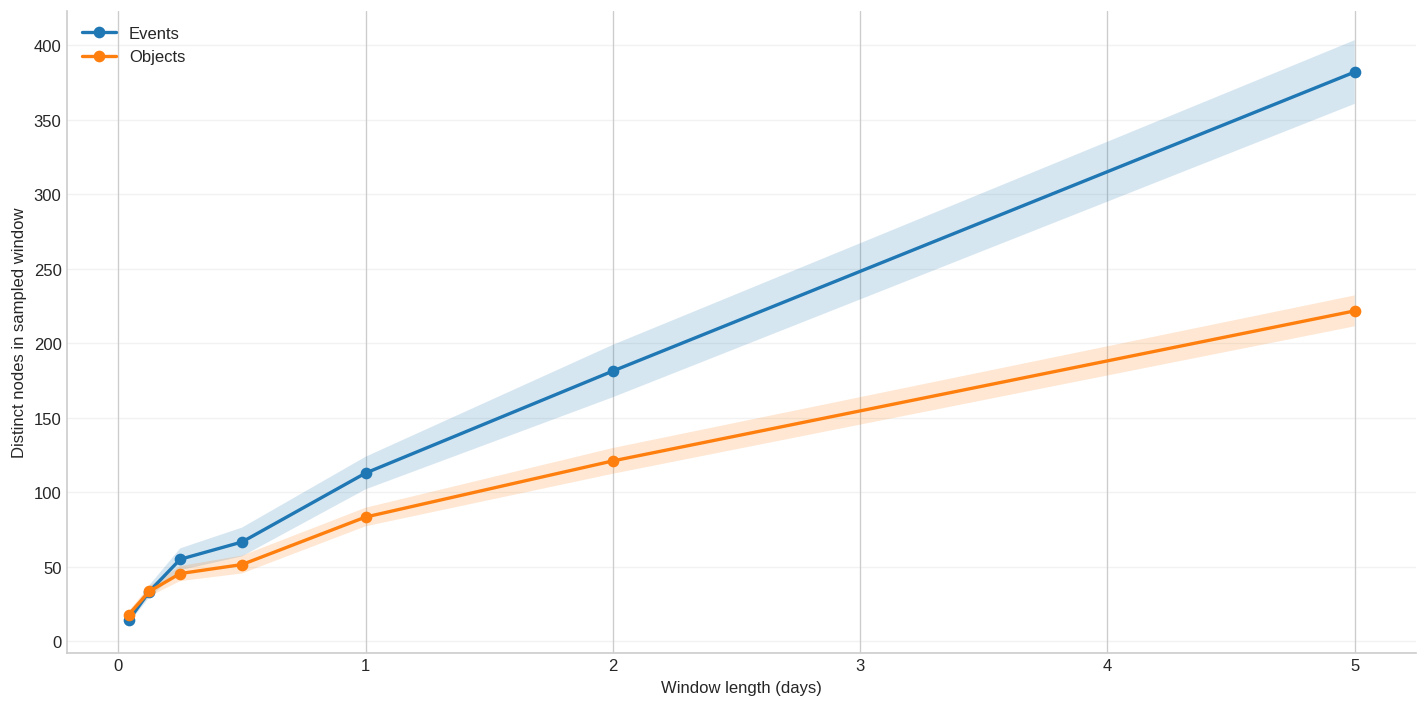

In [8]:
from scripts.inspection.utils import (
    sample_window_graph_sizes,
    save_figure,
    summarize_sampled_window_graph_sizes,
)

window_deltas = ["1h", "3h", "6h", "12h", "1D", "2D", "5D"]
window_num_roots = 100
window_random_state = 0
window_ci = 0.95

window_samples = sample_window_graph_sizes(
    db,
    window_deltas,
    num_roots=window_num_roots,
    random_state=window_random_state,
)
window_summary = summarize_sampled_window_graph_sizes(window_samples, ci=window_ci)

fig, ax = plt.subplots(figsize=(12, 6))
for metric, label in (("event", "Events"), ("object", "Objects")):
    metric_df = window_summary[window_summary["metric"] == metric].sort_values("delta_days")
    ax.plot(metric_df["delta_days"], metric_df["mean"], marker="o", linewidth=2, label=label)
    ax.fill_between(metric_df["delta_days"], metric_df["ci_lower"], metric_df["ci_upper"], alpha=0.18)
ax.set_xlabel("Window length (days)")
ax.set_ylabel("Distinct nodes in sampled window")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()

display(Markdown(
    f"Sampled root times: **{window_num_roots}**  |  Deltas: **{', ' .join(window_deltas)}**  |  CI: **{window_ci:.0%}**"
))
display(fig)
plt.close(fig)
if SAVE_FIGURES:
    save_figure(fig, dataset_name=DATASET_NAME, stem="figures/sampled_window_size_curves")


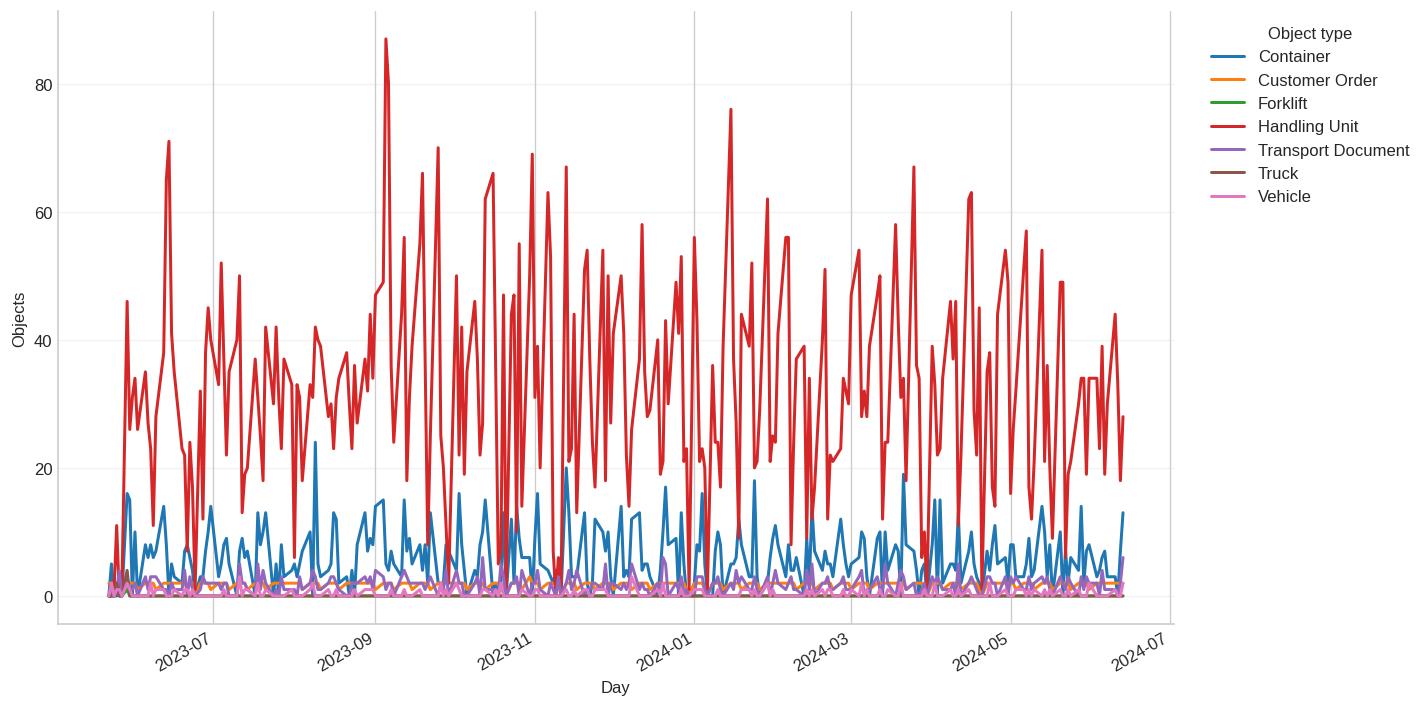

In [9]:
from scripts.inspection.utils import object_histogram, save_figure

object_hist = object_histogram(db, freq="D", by_type=True)
object_hist_pivot = object_hist.pivot(index="bucket", columns="type", values="count").fillna(0).sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
object_hist_pivot.plot(ax=ax, linewidth=1.8)
ax.set_xlabel("Day")
ax.set_ylabel("Objects")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(title="Object type", loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()

display(fig)
plt.close(fig)
if SAVE_FIGURES:
    save_figure(fig, dataset_name=DATASET_NAME, stem="figures/object_histogram_daily_by_type")


## 8. Objects linked per event

This distribution summarizes the event-side degree of the event-object graph. A heavy right tail means some events touch many objects at once, which usually makes the process more strongly object-centric and less case-like.


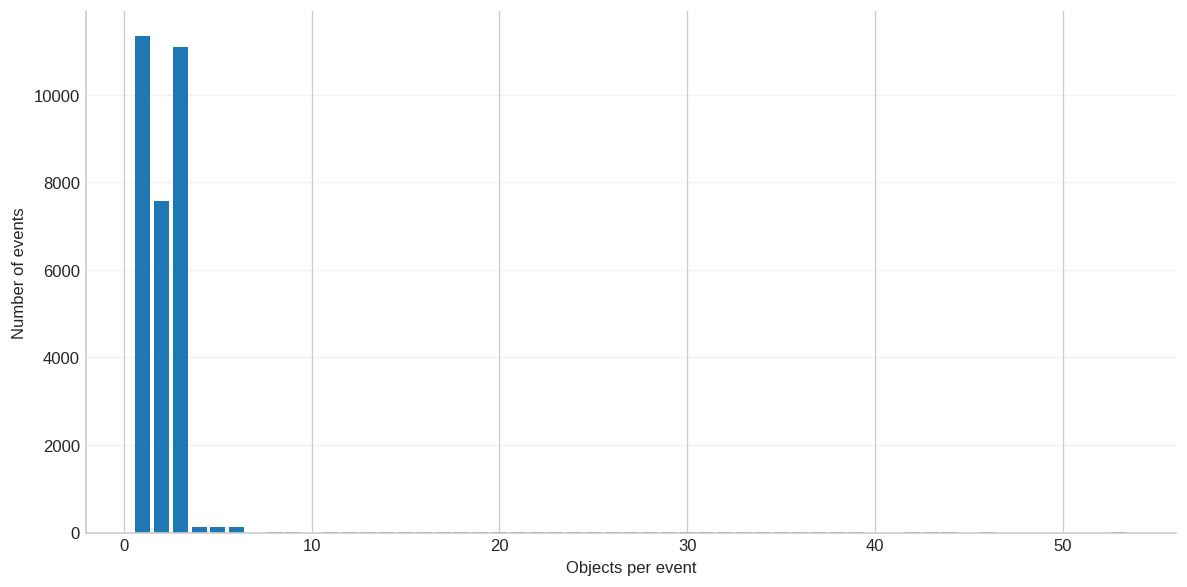

In [10]:
from scripts.inspection.utils import objects_per_event_distribution, save_figure

objects_per_event = objects_per_event_distribution(db)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    objects_per_event["objects_per_event"],
    objects_per_event["num_events"],
    width=0.8,
)
ax.set_xlabel("Objects per event")
ax.set_ylabel("Number of events")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()

display(fig)
plt.close(fig)
if SAVE_FIGURES:
    save_figure(fig, dataset_name=DATASET_NAME, stem="figures/objects_per_event_distribution")


## 9. Events linked per object

This is the object-side view of the same graph. It highlights whether objects are short-lived and touched rarely or whether they accumulate long interaction histories across many events.


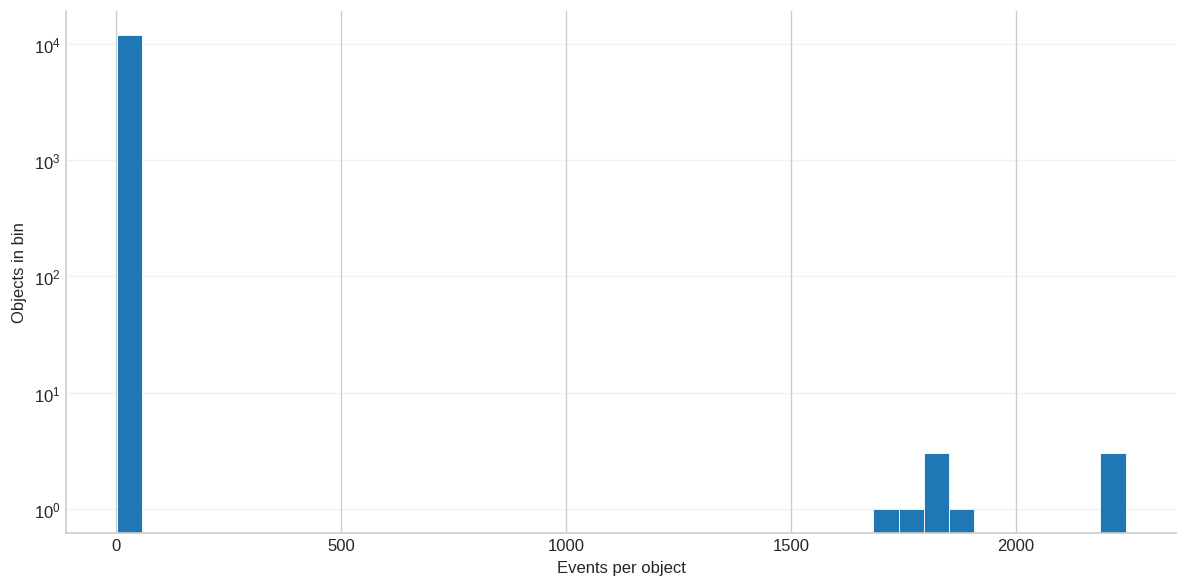

In [11]:
from scripts.inspection.utils import events_per_object_distribution, save_figure

events_per_object = events_per_object_distribution(db)
events_per_object_values = events_per_object.loc[
    events_per_object.index.repeat(events_per_object["num_objects"]),
    "events_per_object",
].to_numpy()
events_per_object_bins = min(40, max(10, int(len(events_per_object_values) ** 0.5)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    events_per_object_values,
    bins=events_per_object_bins,
    edgecolor="white",
    linewidth=0.5,
)
ax.set_xlabel("Events per object")
ax.set_ylabel("Objects in bin")
ax.set_yscale('log')
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()

display(fig)
plt.close(fig)
if SAVE_FIGURES:
    save_figure(fig, dataset_name=DATASET_NAME, stem="figures/events_per_object_distribution")


## 10. Event influence of long-running objects

This curve asks how much of the event log is still covered if we only keep objects whose trace length is at least a given threshold. A slow decline means long-running objects continue to participate in a substantial share of events, which is exactly the influence pattern we want to expose.


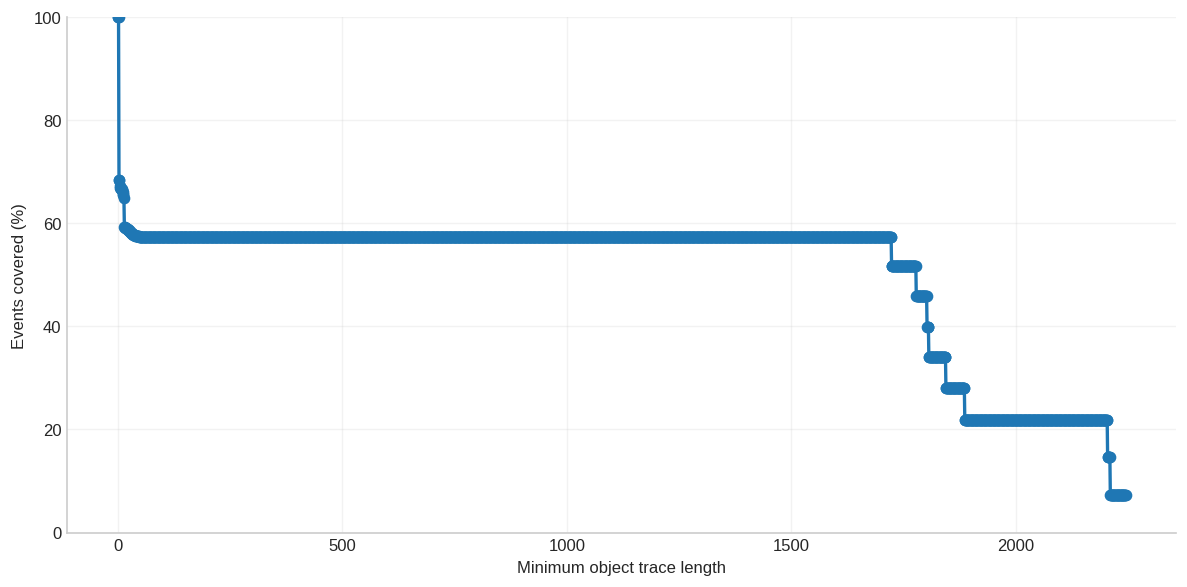

In [12]:
from scripts.inspection.utils import event_share_by_min_object_trace_length, save_figure

_, event_trace_influence = event_share_by_min_object_trace_length(db)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    event_trace_influence["min_object_trace_length"],
    event_trace_influence["event_share_pct"],
    marker="o",
    linewidth=2,
)
ax.set_xlabel("Minimum object trace length")
ax.set_ylabel("Events covered (%)")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.25)
fig.tight_layout()

display(fig)
plt.close(fig)
if SAVE_FIGURES:
    save_figure(fig, dataset_name=DATASET_NAME, stem="figures/event_influence_by_object_trace_length")


## 11. Object retention and type occupation by trace length

This section keeps the trace-length axis explicit. The first plot shows the percentage of objects whose trace length is strictly longer than each threshold. The second plot keeps that same surviving population and shows how its object-type composition changes as the threshold rises.


/tmp/ipykernel_1638850/1531237698.py:21: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 100)


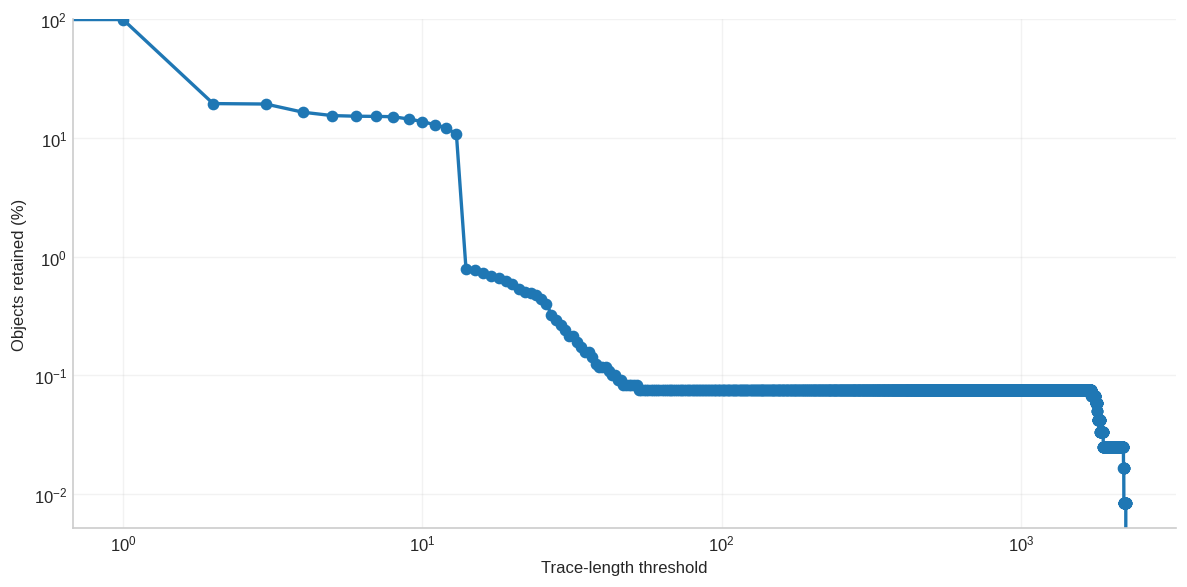

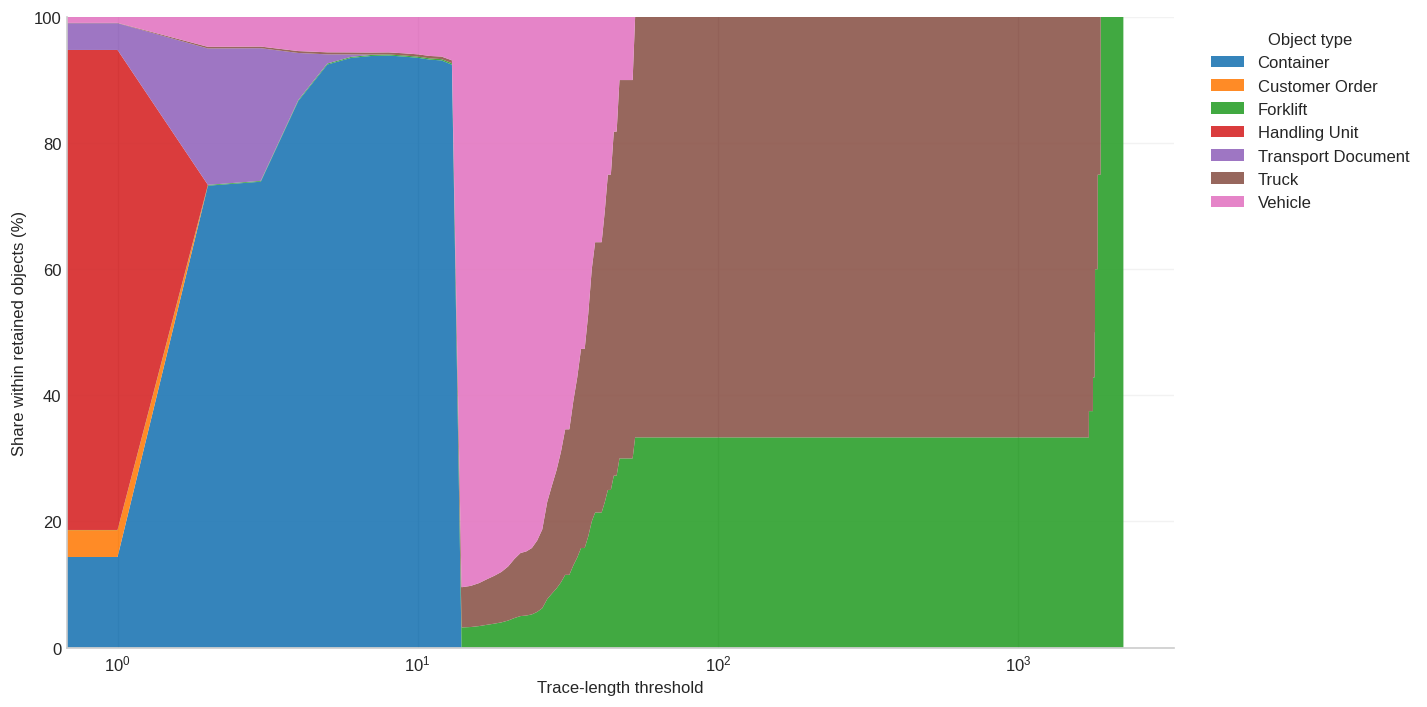

In [22]:
from scripts.inspection.utils import (
    object_share_above_trace_length,
    object_type_occupation_above_trace_length,
    save_figure,
)

_, object_share_by_length = object_share_above_trace_length(db)
_, object_type_occupation = object_type_occupation_above_trace_length(db)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    object_share_by_length["trace_length_threshold"],
    object_share_by_length["object_share_above_threshold_pct"],
    marker="o",
    linewidth=2,
)
ax.set_xlabel("Trace-length threshold")
ax.set_ylabel("Objects retained (%)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.25)
fig.tight_layout()
display(fig)
if SAVE_FIGURES:
    save_figure(fig, dataset_name=DATASET_NAME, stem="figures/object_share_above_trace_length")
plt.close(fig)

occupation_surface = (
    object_type_occupation.pivot(
        index="trace_length_threshold",
        columns="object_type",
        values="type_share_within_threshold_pct",
    )
    .fillna(0)
    .sort_index()
)
fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(
    occupation_surface.index,
    occupation_surface.to_numpy().T,
    labels=occupation_surface.columns,
    alpha=0.9,
)
ax.set_xlabel("Trace-length threshold")
ax.set_ylabel("Share within retained objects (%)")
ax.set_xscale("log")
ax.set_ylim(0, 100)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(title="Object type", loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()

display(fig)
plt.close(fig)
if SAVE_FIGURES:
    save_figure(fig, dataset_name=DATASET_NAME, stem="figures/object_type_occupation_above_trace_length")


## 12. Event attribute completeness

Missing event attributes are often more important than they first look, because they directly constrain which task targets or features can be defined later. Low non-null rates usually mean a field is process-specific or logged only in a subset of event types.


In [14]:
from scripts.inspection.utils import attribute_non_null_summary

display(attribute_non_null_summary(db, kind="event"))


,table,column,rows,non_null,non_null_rate


## 13. Object attribute completeness

The same completeness check on object-side attributes shows which entity descriptors are globally available versus sparsely attached to only a few object types. This is usually the more relevant view for entity-level prediction tasks.


In [15]:
from scripts.inspection.utils import attribute_non_null_summary

display(attribute_non_null_summary(db, kind="object"))


,table,column,rows,non_null,non_null_rate
0,object_attr_Container,AmountofHandlingUnits,5155,5155,1.0
1,object_attr_Container,Status,5155,5155,1.0
2,object_attr_Container,Weight,5155,5155,1.0
3,object_attr_Customer Order,AmountofGoods,514,514,1.0
4,object_attr_Transport Document,AmountofContainers,1495,1495,1.0
5,object_attr_Transport Document,Status,1495,1495,1.0
6,object_attr_Vehicle,DepartureDate,107,107,1.0


## 14. Event-object age matrix

This matrix measures how old linked objects are when different event types occur. Large deltas indicate that the event usually interacts with mature objects, while small deltas suggest the event happens soon after object creation.


In [16]:
from scripts.inspection.utils import event_object_matrix

display(event_object_matrix(db))


,event_type,object_type,n,delta_mean_hours,delta_p50_hours,delta_p90_hours
0,Book Vehicles,Transport Document,508,5.844624,1.658472,15.739139
1,Book Vehicles,Vehicle,651,212.696390,187.277778,479.013333
2,Bring to Loading Bay,Container,1684,311.233164,313.264028,527.756167
3,Bring to Loading Bay,Forklift,1684,4684.139062,4702.377222,8229.375111
4,Collect Goods,Handling Unit,9117,0.000000,0.000000,0.000000
5,Create Transport Document,Customer Order,510,88.387004,70.808611,186.048417
6,Create Transport Document,Transport Document,510,0.000000,0.000000,0.000000
7,Depart,Container,1673,338.428357,352.663611,551.757778
8,Depart,Transport Document,641,320.227251,328.254444,550.183056
9,Depart,Vehicle,107,498.947144,520.958333,649.969278


## 15. Oldest linked objects per event

This summary ranks linked objects by creation time within each event and keeps the oldest few. It is useful when events attach to many objects and you want to see whether the oldest relationships behave differently from the rest.


In [17]:
from scripts.inspection.utils import event_oldest_k_matrix

display(event_oldest_k_matrix(db, k=5))


,event_type,rank,n,delta_mean_hours,delta_p50_hours,delta_p90_hours
0,Book Vehicles,1,508,235.270357,218.426250,500.551167
1,Book Vehicles,2,508,42.004144,1.842500,171.038528
2,Book Vehicles,3,143,4.048759,1.228333,14.420167
3,Bring to Loading Bay,1,1684,4684.346389,4702.377222,8229.375111
4,Bring to Loading Bay,2,1684,311.025836,313.122639,527.756167
5,Collect Goods,1,9117,0.000000,0.000000,0.000000
6,Create Transport Document,1,510,88.387004,70.808611,186.048417
7,Create Transport Document,2,510,0.000000,0.000000,0.000000
8,Depart,1,107,512.366121,523.017500,666.616500
9,Depart,2,107,503.766353,521.506944,664.198167


## 16. Immediate recency of prior object activity

Here the question changes from object age to object recency. The matrix measures how long it has been since each linked object was previously active, which helps reveal whether event types tend to revisit objects quickly or after long dormant periods.


In [18]:
from scripts.inspection.utils import event_object_recent_matrix

display(event_object_recent_matrix(db))


,event_type,object_type,n,prev_delta_mean_hours,prev_delta_p50_hours,prev_delta_p90_hours
0,Book Vehicles,Transport Document,508,5.844624,1.658472,15.739139
1,Book Vehicles,Vehicle,537,77.860590,47.931389,169.679556
2,Bring to Loading Bay,Container,1684,187.217439,165.162083,363.723167
3,Bring to Loading Bay,Forklift,1684,7.958563,0.076667,23.548250
4,Create Transport Document,Customer Order,510,88.387004,70.808611,186.048417
5,Depart,Container,1673,24.985627,24.971667,27.315000
6,Depart,Transport Document,641,271.828027,264.000000,504.000000
7,Depart,Vehicle,107,20.658567,21.775833,25.563222
8,Drive to Terminal,Container,1717,3.014954,1.180278,2.892833
9,Drive to Terminal,Truck,1717,3.014954,1.180278,2.892833


## 17. Multi-lag recency profile

This extends the previous view to several previous object activities. It shows whether the temporal spacing is stable across recent history or whether only the most recent interaction behaves differently.


In [19]:
from scripts.inspection.utils import event_recent_k_matrix

display(event_recent_k_matrix(db, k=5))


,event_type,lag_rank,n,prev_delta_mean_hours,prev_delta_p50_hours,prev_delta_p90_hours
0,Book Vehicles,1,1045,42.851872,6.940833,143.646111
1,Book Vehicles,2,428,148.970456,143.231250,287.160806
2,Book Vehicles,3,326,211.578668,190.545556,357.995556
3,Book Vehicles,4,233,263.562140,261.400000,409.442389
4,Book Vehicles,5,160,312.345941,314.922500,462.746833
5,Bring to Loading Bay,1,3368,97.588001,22.317500,308.914194
6,Bring to Loading Bay,2,3368,98.469359,23.712083,309.299639
7,Bring to Loading Bay,3,3366,103.070126,46.986806,309.409583
8,Bring to Loading Bay,4,3365,105.406380,53.025833,310.600667
9,Bring to Loading Bay,5,3365,111.136445,66.320833,311.669167


## 18. Temporal bin stability sweep

The final diagnostic tests different hour bin widths for weekly activity profiles during the training period. Higher correlation means the week-to-week shape is more stable, which is useful when choosing time discretizations for sampling or baseline models.


In [20]:
from data.const import EVENT_TABLE
from scripts.inspection.utils import summarize_interval_stability

train_end = ds.val_timestamp
train_events = db.table_dict[EVENT_TABLE].upto(train_end).df
candidate_hours = [1, 2, 3, 4, 6, 8, 12, 24]
min_weekly_events = 0

interval_stability = pd.DataFrame(
    [summarize_interval_stability(train_events, hours=h, min_events=min_weekly_events) for h in candidate_hours]
).sort_values(["corr_mean", "corr_p50", "interval_hours"], ascending=[False, False, True]).reset_index(drop=True)

display(Markdown(f"Training events considered: **{len(train_events):,}**  |  Minimum weekly events: **{min_weekly_events:,}**"))
display(interval_stability)


Training events considered: **25,220**  |  Minimum weekly events: **0**

,interval_hours,weeks_ge_min_events,corr_mean,corr_std,corr_min,corr_p10,corr_p50,corr_p90,active_cells
0,24,47,0.760706,0.178037,-0.469453,0.535219,0.803560,0.932959,7
1,8,47,0.745930,0.169896,-0.215549,0.526506,0.789820,0.916938,21
2,6,47,0.741353,0.157890,-0.160716,0.576767,0.775774,0.889034,28
3,12,47,0.676086,0.156281,-0.360235,0.473922,0.699718,0.846276,14
4,4,47,0.661113,0.160283,-0.117696,0.457119,0.691059,0.836523,42
5,3,47,0.639924,0.162454,-0.107099,0.475052,0.671047,0.795615,55
6,2,47,0.562033,0.161693,-0.094913,0.394633,0.584854,0.728930,82
7,1,47,0.354192,0.144535,-0.053103,0.171869,0.356423,0.536895,154
